In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import berserk
import os
from scipy.stats import chi2_contingency
from dotenv import load_dotenv

# Load data
df = pd.read_csv('data/games.csv')
df.dropna(subset=['white_rating', 'black_rating', 'opening_name', 'winner'], inplace=True)

# Feature Engineering: Rating Brackets
bins = [0, 1200, 1800, 3000]
labels = ['Beginner', 'Intermediate', 'Advanced']
df['rating_bracket'] = pd.cut(df['white_rating'], bins=bins, labels=labels)

print(f"Dataset loaded with {len(df)} records.")   

Dataset loaded with 20058 records.


# Focus on Top 10 most frequent openings
top_10_openings = df['opening_name'].value_counts().nlargest(10).index
df_top_10 = df[df['opening_name'].isin(top_10_openings)]

# Chi-Square Test
contingency_table = pd.crosstab(df_top_10['opening_name'], df_top_10['rating_bracket'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("Result: Reject the Null Hypothesis. Opening choice depends on player skill level.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")

In [2]:
# Focus on Top 10 most frequent openings
top_10_openings = df['opening_name'].value_counts().nlargest(10).index
df_top_10 = df[df['opening_name'].isin(top_10_openings)]

# Chi-Square Test
contingency_table = pd.crosstab(df_top_10['opening_name'], df_top_10['rating_bracket'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("Result: Reject the Null Hypothesis. Opening choice depends on player skill level.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")

Chi-Square Statistic: 248.3951
P-value: 1.7287e-42
Result: Reject the Null Hypothesis. Opening choice depends on player skill level.


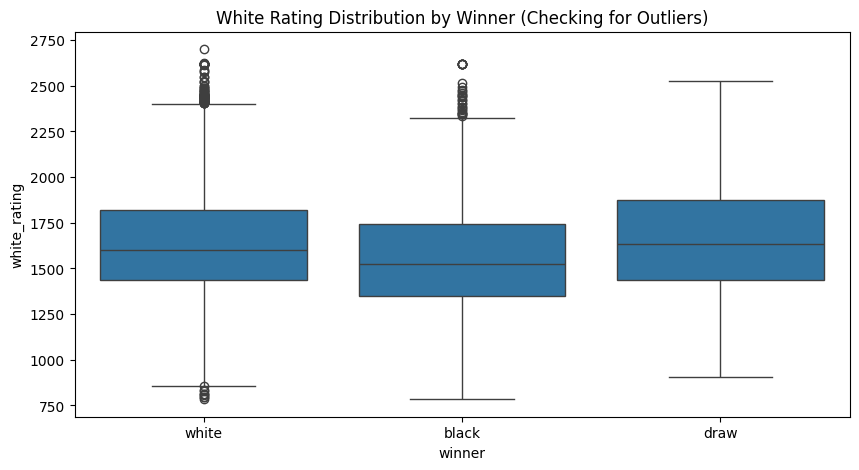

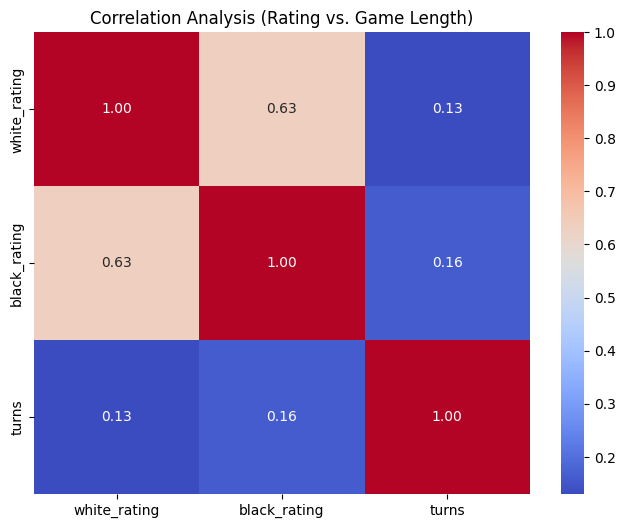

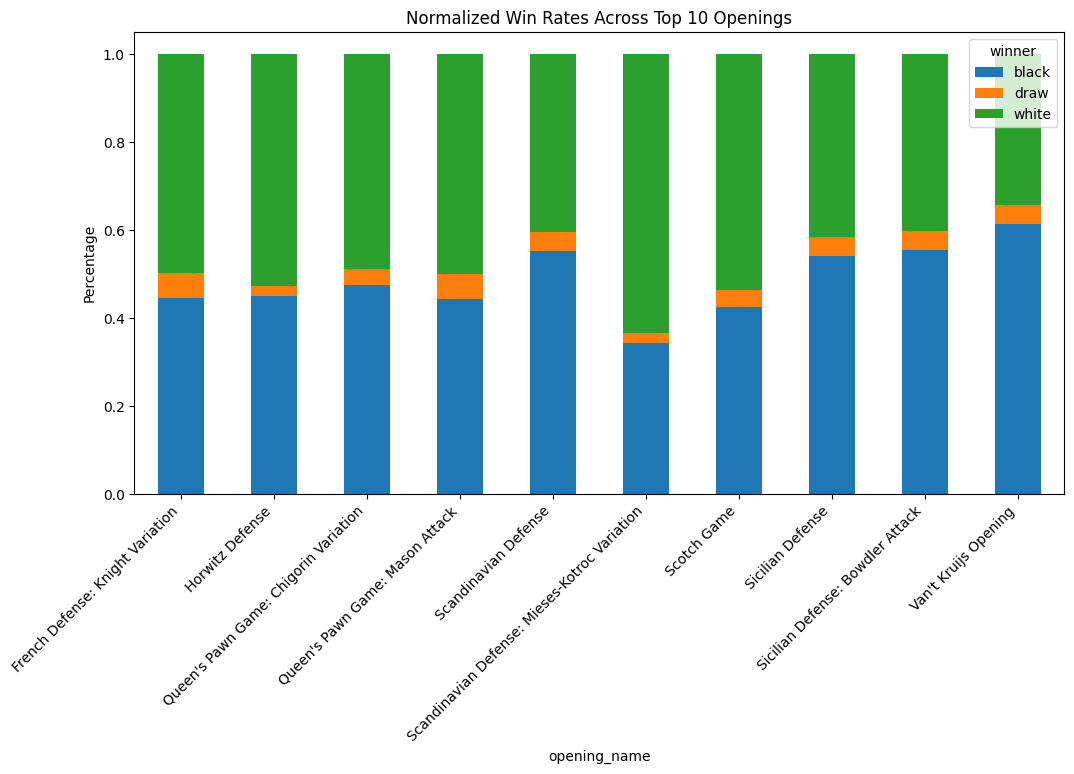

In [3]:
# 1. Distribution of Ratings by Winner (Outlier Detection)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='winner', y='white_rating')
plt.title('White Rating Distribution by Winner (Checking for Outliers)')
plt.show()

# 2. Correlation Heatmap
# Selecting numerical columns for correlation
plt.figure(figsize=(8, 6))
correlation_matrix = df[['white_rating', 'black_rating', 'turns']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Analysis (Rating vs. Game Length)')
plt.show()

# 3. Win Rate per Opening (Factor Analysis)
win_rates = df_top_10.groupby('opening_name')['winner'].value_counts(normalize=True).unstack()
win_rates.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Normalized Win Rates Across Top 10 Openings')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.show()